Preliminaries

In [1]:
import importlib
import coupling_utils as cl
import element
import numpy as np

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import pandas as pd
import gc

In [3]:
import vegas

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [5]:
m_t = 173

Checks

In [6]:
N = 10
X = torch.rand(N, 5, device=device, dtype=torch.float64)
(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
print(P.shape, P1.shape, P2.shape, P3.shape, jac_map.shape)


torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10])


In [7]:
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [8]:
me_values = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=np.float64) * jac_map
print(me_values)

tensor([ 561210.7412, 1387194.9005,  192269.3691,   29217.2534,  112263.4475,
         504700.5621,  225163.8329,   31484.5428,  107831.9451,  485719.8411],
       device='cuda:0', dtype=torch.float64)


In [6]:
def test_costheta2_raw(N=100000, m_t=173.0):
    X = torch.rand(N, 5, dtype=torch.float64)
    u0, u1 = X[:, 0], X[:, 1]

    E1 = 0.5 * m_t * torch.sqrt(u0)
    E2 = (0.5 * m_t - E1) + E1 * u1

    a = m_t**2 - 2*m_t*E1 - 2*m_t*E2 + 2*E1*E2
    b = 2*E1*E2
    c = a / b

    print("raw costheta2 min:", c.min().item())
    print("raw costheta2 max:", c.max().item())
    print("count raw < -1:", (c < -1).sum().item())
    print("count raw > 1:", (c > 1).sum().item())


test_costheta2_raw()

raw costheta2 min: -0.9999988994717769
raw costheta2 max: 0.9999487287025257
count raw < -1: 0
count raw > 1: 0


Train flow

In [7]:
A_dims = [torch.tensor([1, 2, 3, 4]),
          torch.tensor([0, 2, 3, 4]),
          torch.tensor([0, 1, 3, 4]),
          torch.tensor([0, 1, 2, 4]),
          torch.tensor([0, 1, 2, 3])]
                

B_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([2]),
          torch.tensor([3]),
          torch.tensor([4])]
                

In [8]:
torch.manual_seed(0)
Y_probe = torch.rand((50000, 5), device=device, dtype=torch.float64)

In [9]:
#check integral - integrate one
N_test = 1_000_000
batch_size = 100_000

test_flow = cl.normalising_flow(
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    min_bin_width=1e-3
)

device = next(test_flow.parameters()).device
dtype = torch.float64  # recommended for this check
test_flow = test_flow.to(device=device, dtype=dtype)
test_flow.eval()

sum_jac = torch.tensor(0.0, device=device, dtype=dtype)
sum_jac2 = torch.tensor(0.0, device=device, dtype=dtype)
n_done = 0

with torch.inference_mode():
    for start in range(0, N_test, batch_size):
        b = min(batch_size, N_test - start)

        Y_batch = torch.rand((b, 5), device=device, dtype=dtype)
        _, jacobian_batch = test_flow.inverse(Y_batch)

        #jacobian_batch = jacobian_batch.reshape(-1)

        sum_jac += jacobian_batch.sum()
        sum_jac2 += (jacobian_batch**2).sum()
        n_done += b

mean_jac = sum_jac / n_done
var_jac = sum_jac2 / n_done - mean_jac**2
var_jac = torch.clamp(var_jac, min=0.0)
std_jac = torch.sqrt(var_jac)
error = std_jac / torch.sqrt(torch.tensor(n_done, device=device, dtype=dtype))

print(mean_jac.item(), error.item())

0.999733187189402 0.00023864107592113472


In [10]:
class PartialComposition(torch.nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = torch.nn.ModuleList(layers)

    def forward(self, x):
        y = x
        for layer in self.layers:
            y = layer(y)
        return y

    def inverse(self, y):
        x = y
        jac_dets = torch.ones(y.shape[0], device=y.device, dtype=y.dtype)
        for layer in reversed(list(self.layers)):
            x, jac = layer.inverse(x)
            jac_dets = jac_dets * jac
        return x, jac_dets
    
@torch.inference_mode()
def unit_test_partial_layers(flow, D, N=100000, batch_size=20000):
    for n in range(1, len(flow.layers) + 1):
        subflow = PartialComposition(flow.layers[:n]).to(next(flow.parameters()).device)
        sum_jac = torch.tensor(0.0, device=next(flow.parameters()).device, dtype=next(flow.parameters()).dtype)
        sum_jac2 = torch.tensor(0.0, device=next(flow.parameters()).device, dtype=next(flow.parameters()).dtype)
        n_done = 0

        for start in range(0, N, batch_size):
            b = min(batch_size, N - start)
            Y = torch.rand((b, D), device=next(flow.parameters()).device, dtype=next(flow.parameters()).dtype)
            _, jac = subflow.inverse(Y)
            sum_jac += jac.sum()
            sum_jac2 += (jac**2).sum()
            n_done += b

        mean = sum_jac / n_done
        var = torch.clamp(sum_jac2 / n_done - mean**2, min=0.0)
        err = torch.sqrt(var) / torch.sqrt(torch.tensor(n_done, device=mean.device, dtype=mean.dtype))
        print(f"Layers 1..{n}: {mean.item():.6f} ± {err.item():.6f}")

In [11]:
unit_test_partial_layers(test_flow, 5, 100000, 50000)

Layers 1..1: 1.000262 ± 0.000360
Layers 1..2: 1.000231 ± 0.000460
Layers 1..3: 0.999600 ± 0.000591
Layers 1..4: 1.000038 ± 0.000700
Layers 1..5: 0.998624 ± 0.000757


In [10]:
@torch.inference_mode()
def round_trip_test(flow, D, N=100000, device='cpu', dtype=torch.float64):
    Y = torch.rand((N, D), device=device, dtype=dtype)
    X, _ = flow.inverse(Y)
    Y_rec = flow.forward(X)

    err_y = (Y_rec - Y).abs()
    print("forward(inverse(y)):")
    print("  mean abs err:", err_y.mean().item())
    print("  max  abs err:", err_y.max().item())

    X0 = torch.rand((N, D), device=device, dtype=dtype)
    Y0 = flow.forward(X0)
    X_rec, _ = flow.inverse(Y0)

    err_x = (X_rec - X0).abs()
    print("inverse(forward(x)):")
    print("  mean abs err:", err_x.mean().item())
    print("  max  abs err:", err_x.max().item())

In [11]:
round_trip_test(test_flow, 5, 100000, device='cpu', dtype=torch.float64)

forward(inverse(y)):
  mean abs err: 1.7181897857151072e-16
  max  abs err: 9.276468482255495e-13
inverse(forward(x)):
  mean abs err: 1.7397180104936767e-16
  max  abs err: 3.418820782030707e-12


In [8]:
@torch.inference_mode()
def check_actual_layer_floors(flow, Y_probe):       #pwl only
    for i, layer in enumerate(flow.layers):
        y_A = Y_probe[:, layer.A_dims]
        B = Y_probe.size(0)

        raw_heights = layer.heights_net(y_A).reshape(B, layer.D_B, layer.K - 1)
        raw_widths  = layer.widths_net(y_A).reshape(B, layer.D_B, layer.K)

        # IMPORTANT: call exactly the same functions that layer.inverse/forward should use
        heights = layer._heights_from_raw(raw_heights) if hasattr(layer, "_heights_from_raw") else None
        bins    = layer._bins_from_raw(raw_widths) if hasattr(layer, "_bins_from_raw") else None

        print(f"layer {i}")
        if heights is None or bins is None:
            print("  No helper methods found on layer; cannot verify actual path.")
            continue

        widths = bins[..., 1:] - bins[..., :-1]

        zeros = torch.zeros((B, layer.D_B, 1), device=Y_probe.device, dtype=Y_probe.dtype)
        ones  = torch.ones((B, layer.D_B, 1), device=Y_probe.device, dtype=Y_probe.dtype)
        cdf = torch.cat([zeros, heights, ones], dim=-1)
        cdf_incs = cdf[..., 1:] - cdf[..., :-1]

        print("  width_min:", widths.min().item())
        print("  cdf_inc_min:", cdf_incs.min().item())


check_actual_layer_floors(test_flow, Y_probe.cpu())

NameError: name 'test_flow' is not defined

In [11]:
for i, layer in enumerate(test_flow.layers):
    print("layer", i)
    print("type:", type(layer))
    print("min_bin_width:", getattr(layer, "min_bin_width", None))
    #print("min_cdf_inc:", getattr(layer, "min_cdf_inc", None))

layer 0
type: <class 'coupling_utils.pwq_layer'>
min_bin_width: 0.001
layer 1
type: <class 'coupling_utils.pwq_layer'>
min_bin_width: 0.001
layer 2
type: <class 'coupling_utils.pwq_layer'>
min_bin_width: 0.001
layer 3
type: <class 'coupling_utils.pwq_layer'>
min_bin_width: 0.001
layer 4
type: <class 'coupling_utils.pwq_layer'>
min_bin_width: 0.001


In [ ]:
#check phase space integral

(_, _, _, _), map_jac = element.hypercube_to_momenta(X_test, m_t)
ps_estimate = (jacobian * map_jac).mean()
ps_error = torch.std(jacobian * map_jac) / torch.sqrt(torch.tensor(N_test))
print(ps_estimate.item(), ps_error.item())

In [10]:
@torch.inference_mode()
def inspect_pwl_layer_geometry(flow, Y_probe):
    """
    Y_probe: (B, D) points in [0,1]^D used to probe the conditioning
    Returns per-layer summaries of widths and cdf increments.
    """

    summaries = []

    for layer_idx, layer in enumerate(flow.layers):
        # Use the same conditioning variable that inverse() uses
        y_A = Y_probe[:, layer.A_dims]
        B = Y_probe.size(0)

        raw_heights = layer.heights_net(y_A).reshape(B, layer.D_B, layer.K - 1)
        raw_widths  = layer.widths_net(y_A).reshape(B, layer.D_B, layer.K)

        heights = layer._heights_from_raw(raw_heights)
        bins = layer._bins_from_raw(raw_widths)

        # widths in x-space
        widths = bins[..., 1:] - bins[..., :-1]              # (B, D_B, K)

        # cdf increments in y-space
        zeros = torch.zeros((B, layer.D_B, 1), device=Y_probe.device, dtype=Y_probe.dtype)
        ones  = torch.ones((B, layer.D_B, 1), device=Y_probe.device, dtype=Y_probe.dtype)
        cdf = torch.cat([zeros, heights, ones], dim=-1)      # (B, D_B, K+1)
        cdf_incs = cdf[..., 1:] - cdf[..., :-1]              # (B, D_B, K)

        # inverse slopes dx/dy for each local segment
        inv_slopes = widths / cdf_incs

        summary = {
            "layer": layer_idx,
            "width_min": widths.min().item(),
            "width_mean": widths.mean().item(),
            "width_max": widths.max().item(),

            "cdf_inc_min": cdf_incs.min().item(),
            "cdf_inc_mean": cdf_incs.mean().item(),
            "cdf_inc_max": cdf_incs.max().item(),

            "inv_slope_min": inv_slopes.min().item(),
            "inv_slope_mean": inv_slopes.mean().item(),
            "inv_slope_max": inv_slopes.max().item(),
        }
        summaries.append(summary)

    return summaries

In [11]:
before = inspect_pwl_layer_geometry(test_flow, Y_probe.cpu())


print("Before:")
for s in before:
    print(s)


Before:
{'layer': 0, 'width_min': 0.010670019029791145, 'width_mean': 0.015625, 'width_max': 0.02077477615695611, 'cdf_inc_min': 0.00846972031380866, 'cdf_inc_mean': 0.015625, 'cdf_inc_max': 0.026443335174573035, 'inv_slope_min': 0.6282258110043974, 'inv_slope_mean': 1.0228687657951785, 'inv_slope_max': 1.7272402429137972}
{'layer': 1, 'width_min': 0.010925463232247412, 'width_mean': 0.015625, 'width_max': 0.02062308883697042, 'cdf_inc_min': 0.010598103191059804, 'cdf_inc_mean': 0.015625, 'cdf_inc_max': 0.022876922285911594, 'inv_slope_min': 0.6753644973351904, 'inv_slope_mean': 1.0175434870648354, 'inv_slope_max': 1.6793975150149039}
{'layer': 2, 'width_min': 0.010509627110862452, 'width_mean': 0.015625, 'width_max': 0.020545936824921673, 'cdf_inc_min': 0.011338572477361752, 'cdf_inc_mean': 0.015625, 'cdf_inc_max': 0.021407334780042975, 'inv_slope_min': 0.5281397008818537, 'inv_slope_mean': 1.0183052715524332, 'inv_slope_max': 1.5459152131967322}
{'layer': 3, 'width_min': 0.0103334498

In [ ]:
final_loss, loss_values, flow, diagnostics = cl.train_loop_decay_diagnostic_2(
    D=5,
    layer_type=cl.pwl_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    N=8000,
    epochs=6000,
    lr=2e-5,
    device=device,
    dtype=np.float64,
    ticker=True,
    print_every=20,
    unit_test_every=100,
    unit_test_samples=100_000,
    clip_grad=10.0,
    m_t=173,
    geometry_every=20,
    geometry_probe_size=5000
)

Initial normalisation scale: 2.422413e+07
Epoch     0 | loss=1.166812e+00 | main=1.166736e+00 | geom_pen=7.629706e-05 | lr=2.000e-05 | jac_mean=9.958364e-01 | jac_std=5.280429e-01 | jac_min=1.029294e-01 | jac_max=5.316044e+00 | jac_map_mean=2.953874e+05 | h_std=2.616419e+07 | grad_norm=3.774124e+00 | unit_int=9.979751e-01 ± 1.68e-03 | width[min,max]=(9.964e-03, 2.379e-02) | cdf_inc[min,max]=(8.875e-03, 3.018e-02) | inv_slope[min,max]=(4.533e-01, 2.303e+00)
  Layer penalties:
    layer 0: lambda_slope=9.000e-04 | slope_penalty=5.852e-02 | width_penalty=2.468e-02 | cdf_penalty=3.339e-02 | layer_penalty=5.267e-05
    layer 1: lambda_slope=2.000e-04 | slope_penalty=4.209e-02 | width_penalty=2.135e-02 | cdf_penalty=2.235e-02 | layer_penalty=8.417e-06
    layer 2: lambda_slope=1.000e-04 | slope_penalty=5.207e-02 | width_penalty=2.514e-02 | cdf_penalty=2.804e-02 | layer_penalty=5.207e-06
    layer 3: lambda_slope=1.000e-04 | slope_penalty=4.975e-02 | width_penalty=2.577e-02 | cdf_penalty=2.75

In [14]:
final_loss, loss_values, flow, diagnostics = cl.train_loop_decay_diagnostic(
    D=5,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    N=8000,
    epochs=6500,
    lr=2e-5,
    device=device,
    dtype=np.float64,
    ticker=True,
    print_every=20,
    unit_test_every=100,
    unit_test_samples=200_000,
    clip_grad=10.0
)

Initial normalisation scale: 1.920069e+07
Epoch     0 | loss=1.208249e+00 | jac_mean=1.004907e+00 | jac_std=2.325988e-01 | jac_min=3.885740e-01 | jac_max=2.427735e+00 | jac_map_mean=2.953874e+05 | h_std=2.110415e+07 | grad_norm=2.341409e+00 | unit_int=1.000695e+00 ± 5.09e-04
Epoch    20 | loss=1.112581e+00 | jac_mean=9.983898e-01 | jac_std=2.263521e-01 | jac_min=4.242327e-01 | jac_max=2.127330e+00 | jac_map_mean=2.953874e+05 | h_std=2.025142e+07 | grad_norm=2.202744e+00
Epoch    40 | loss=1.309909e+00 | jac_mean=1.004891e+00 | jac_std=2.288147e-01 | jac_min=4.136767e-01 | jac_max=2.373800e+00 | jac_map_mean=2.953874e+05 | h_std=2.197406e+07 | grad_norm=2.729548e+00
Epoch    60 | loss=1.069517e+00 | jac_mean=1.000055e+00 | jac_std=2.288512e-01 | jac_min=4.221348e-01 | jac_max=2.313798e+00 | jac_map_mean=2.953874e+05 | h_std=1.985563e+07 | grad_norm=2.248855e+00
Epoch    80 | loss=1.169714e+00 | jac_mean=1.001622e+00 | jac_std=2.270359e-01 | jac_min=4.188640e-01 | jac_max=2.301096e+00 | 

In [12]:
final_loss, loss_values, flow = cl.train_loop_decay(
    D=5,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    N=8000,
    epochs=6500,
    lr=3e-5,
    device=device,
    dtype=np.float64,
    ticker=True
)

Normalisation scale: 20916877.431161687
Epoch: 0 | Loss: 9.90453824e-01
Mean value:  4754924.2087745685
Std h : 20816799.924673334
Epoch: 20 | Loss: 9.91149544e-01
Mean value:  4607575.471727412
Std h : 20824109.767764755
Epoch: 40 | Loss: 7.68720017e-01
Mean value:  4022654.7874190034
Std h : 18339223.63274503
Epoch: 60 | Loss: 9.55111686e-01
Mean value:  4587113.465006632
Std h : 20442025.743836276
Epoch: 80 | Loss: 7.99623443e-01
Mean value:  4127834.3998316363
Std h : 18704220.367419302
Epoch: 100 | Loss: 9.17247949e-01
Mean value:  4563277.104715382
Std h : 20032734.088243052
Epoch: 120 | Loss: 9.03920147e-01
Mean value:  4272545.91723347
Std h : 19886661.64962769
Epoch: 140 | Loss: 8.54101354e-01
Mean value:  4480741.196479163
Std h : 19330876.968922447
Epoch: 160 | Loss: 8.11007847e-01
Mean value:  4267754.869066208
Std h : 18836897.717992585
Epoch: 180 | Loss: 8.74304497e-01
Mean value:  4426714.929373334
Std h : 19558169.592111617
Epoch: 200 | Loss: 8.55167730e-01
Mean value: 

In [12]:
def plot_layer_geometry_from_diagnostics(diagnostics, n_layers=None, layers=None):
    """
    Plot tracked layer-geometry quantities against epoch from the diagnostics list.

    Expected keys in each diagnostics record:
      - "epoch"
      - f"layer{li}_width_min", f"layer{li}_width_max"
      - f"layer{li}_cdf_inc_min", f"layer{li}_cdf_inc_max"
      - f"layer{li}_inv_slope_max"

    Parameters
    ----------
    diagnostics : list[dict]
        Output from train_loop_decay_diagnostic(...).
    n_layers : int or None
        Number of layers to plot if `layers` is not provided.
    layers : list[int] or None
        Explicit layer indices to plot. Overrides n_layers.

    Returns
    -------
    None
    """

    if len(diagnostics) == 0:
        raise ValueError("diagnostics is empty")

    # Keep only records that actually contain geometry
    geom_records = [r for r in diagnostics if "layer0_width_min" in r]
    if len(geom_records) == 0:
        raise ValueError("No layer geometry found in diagnostics")

    epochs = [r["epoch"] for r in geom_records]

    # Infer layers if not given
    if layers is None:
        if n_layers is None:
            inferred = []
            i = 0
            while f"layer{i}_width_min" in geom_records[0]:
                inferred.append(i)
                i += 1
            if len(inferred) == 0:
                raise ValueError("Could not infer layer indices from diagnostics")
            layers = inferred
        else:
            layers = list(range(n_layers))

    # ---- width_min ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{li}_width_min", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {li}")
    plt.xlabel("Epoch")
    plt.ylabel("width_min")
    plt.title("Minimum bin width by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- width_max ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{li}_width_max", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {li}")
    plt.xlabel("Epoch")
    plt.ylabel("width_max")
    plt.title("Maximum bin width by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- cdf_inc_min ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{li}_cdf_inc_min", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {li}")
    plt.xlabel("Epoch")
    plt.ylabel("cdf_inc_min")
    plt.title("Minimum CDF increment by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- cdf_inc_max ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{li}_cdf_inc_max", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {li}")
    plt.xlabel("Epoch")
    plt.ylabel("cdf_inc_max")
    plt.title("Maximum CDF increment by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- inv_slope_max ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{li}_inv_slope_max", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {li}")
    plt.xlabel("Epoch")
    plt.ylabel("inv_slope_max")
    plt.title("Maximum inverse slope by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

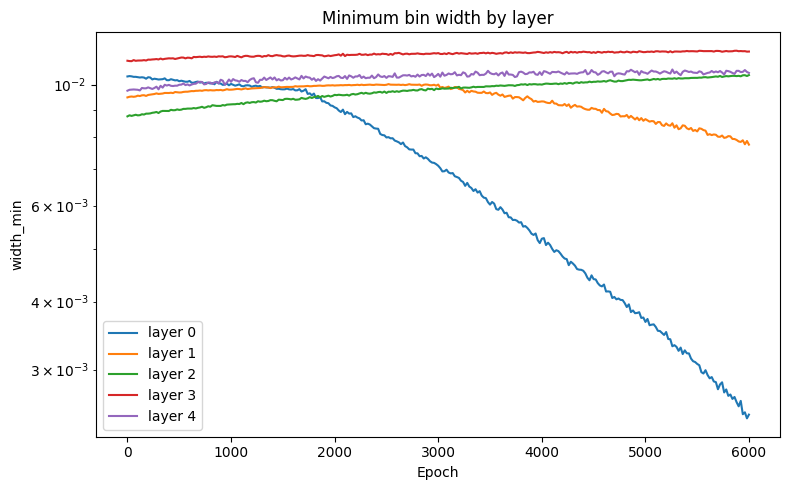

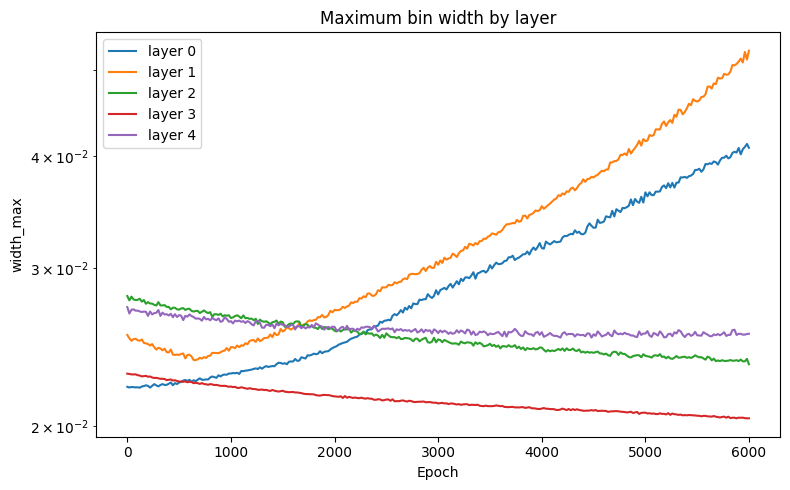

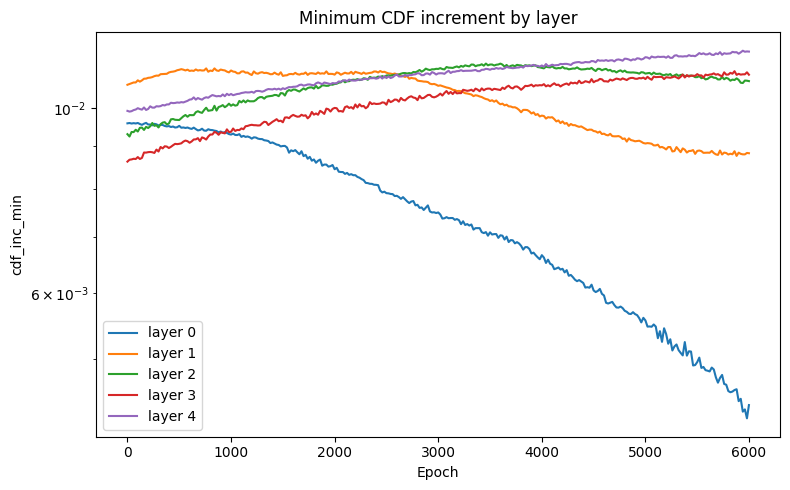

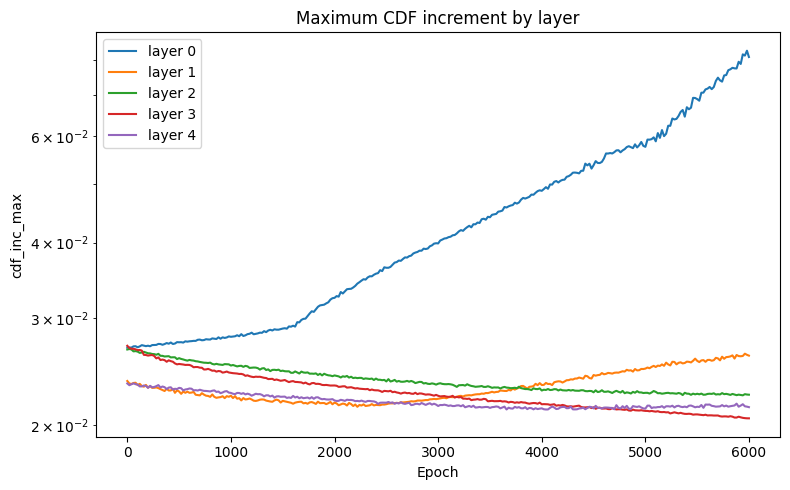

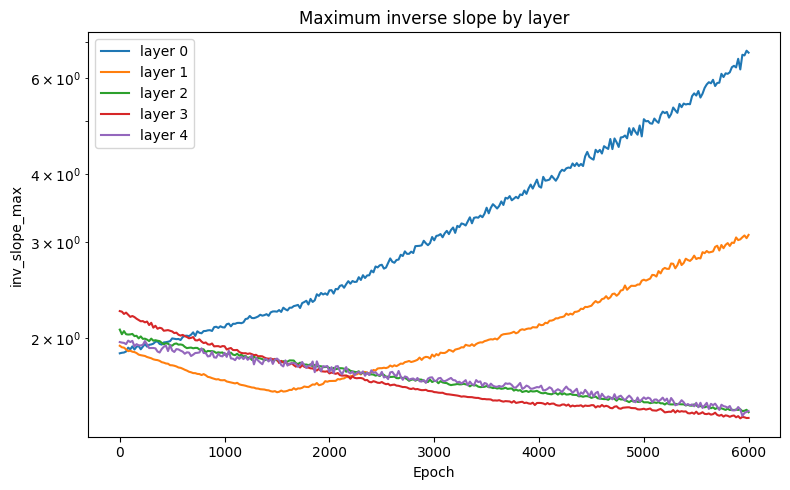

In [10]:
plot_layer_geometry_from_diagnostics(diagnostics, n_layers=5)

In [15]:
unit_test_partial_layers(flow, 5, 100000, 50000)

Layers 1..1: 0.992665 ± 0.006932
Layers 1..2: 1.016260 ± 0.009882
Layers 1..3: 0.994245 ± 0.010521
Layers 1..4: 1.007388 ± 0.010123
Layers 1..5: 1.003705 ± 0.009086


In [16]:
Y_probe_after = torch.rand(100000, 5, dtype=torch.float64)
flow = flow.to('cpu')
after  = inspect_pwl_layer_geometry(flow, Y_probe_after.cpu())
print("\nAfter:")
for s in after:
    print(s)


After:
{'layer': 0, 'width_min': 0.0028254217294479966, 'width_mean': 0.015625, 'width_max': 0.044344165862096385, 'cdf_inc_min': 0.002657426533949514, 'cdf_inc_mean': 0.015625, 'cdf_inc_max': 0.15930457594571223, 'inv_slope_min': 0.025523860150612927, 'inv_slope_mean': 1.4913314995278097, 'inv_slope_max': 8.078803170749298}
{'layer': 1, 'width_min': 0.010242220427999882, 'width_mean': 0.015625, 'width_max': 0.02677881420724093, 'cdf_inc_min': 0.007247030646309938, 'cdf_inc_mean': 0.015625, 'cdf_inc_max': 0.022475423061834948, 'inv_slope_min': 0.5926412718058597, 'inv_slope_mean': 1.041904431471675, 'inv_slope_max': 2.3411800667619977}
{'layer': 2, 'width_min': 0.011103488167968023, 'width_mean': 0.015625, 'width_max': 0.021053119483467223, 'cdf_inc_min': 0.011948822938747605, 'cdf_inc_mean': 0.015625, 'cdf_inc_max': 0.022046955942506746, 'inv_slope_min': 0.6891091662060463, 'inv_slope_mean': 1.0062704314966349, 'inv_slope_max': 1.4602634689669078}
{'layer': 3, 'width_min': 0.01034987

In [15]:
round_trip_test(flow, 5, 100000, device='cpu')

NameError: name 'round_trip_test' is not defined

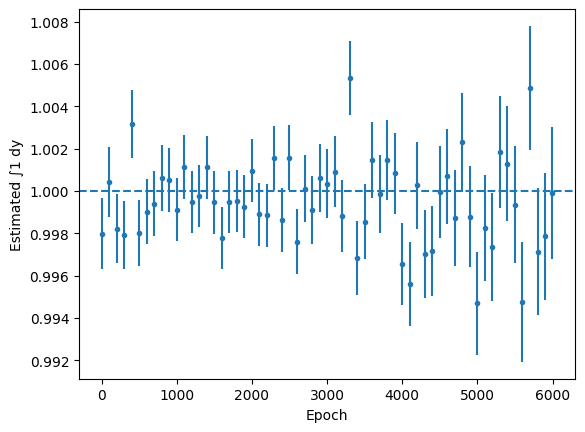

In [17]:
#unit integral drift

epochs = [d["epoch"] for d in diagnostics if "unit_int_mean" in d]
means  = [d["unit_int_mean"] for d in diagnostics if "unit_int_mean" in d]
errors = [d["unit_int_error"] for d in diagnostics if "unit_int_mean" in d]

plt.errorbar(epochs, means, yerr=errors, fmt='.')
plt.axhline(1.0, linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Estimated ∫1 dy")
plt.show()

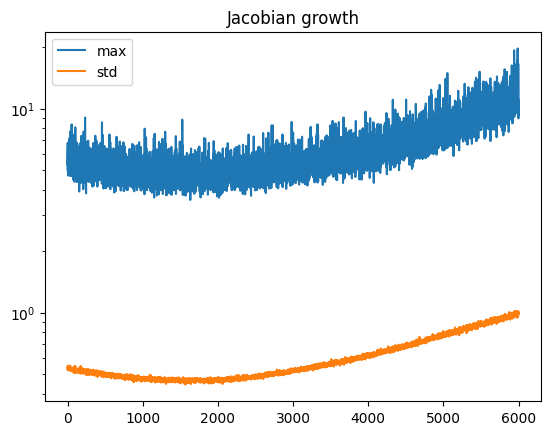

In [18]:
#jacobian tail growth
jac_max = [d["jac_max"] for d in diagnostics]
jac_min = [d["jac_min"] for d in diagnostics]
jac_std = [d["jac_std"] for d in diagnostics]

plt.plot(jac_max, label="max")
plt.plot(jac_std, label="std")
plt.yscale("log")
plt.legend()
plt.title("Jacobian growth")
plt.show()

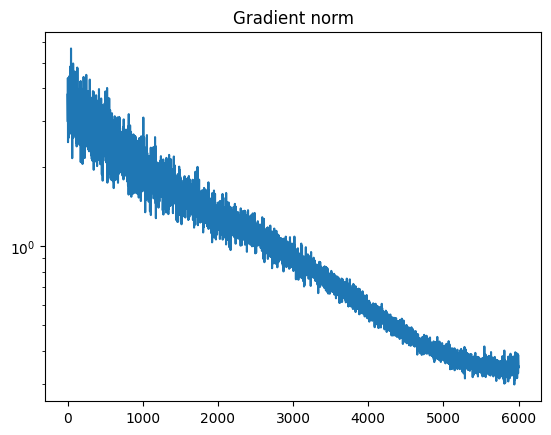

In [19]:
#check gradient behaviour

grad_norm = [d["postclip_grad_norm"] for d in diagnostics]

plt.plot(grad_norm)
plt.yscale("log")
plt.title("Gradient norm")
plt.show()

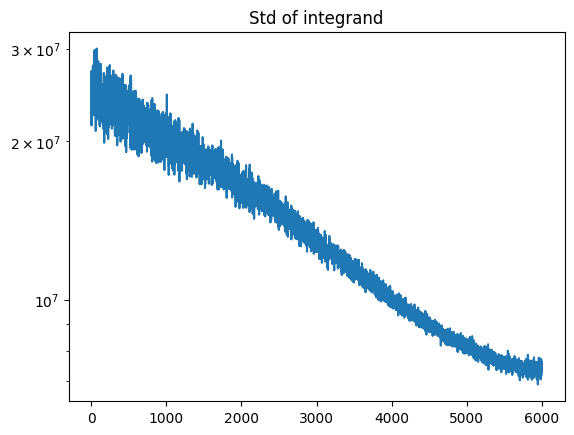

In [20]:
#check training pressure

h_std = [d["h_std"] for d in diagnostics]

plt.plot(h_std)
plt.yscale("log")
plt.title("Std of integrand")
plt.show()

In [16]:
#check integral after
N_test = 1_000_000
batch_size = 100_000
flow = flow.to('cpu')
flow.eval()

sum_jac_after = 0.0
sum_jac2_after = 0.0
n_done_a = 0

with torch.inference_mode():
    for start in range(0, N_test, batch_size):
        b = min(batch_size, N_test - start)

        Y_batch = torch.rand(b, 5, dtype=torch.float64)
        X_batch, jac_after = flow.inverse(Y_batch)

        sum_jac_after += jac_after.sum()
        sum_jac2_after += (jac_after**2).sum()
        n_done_a += b

mean_jac_after = sum_jac_after / n_done_a
var_jac_after = sum_jac2_after / n_done_a - mean_jac_after**2
std_jac_after = torch.sqrt(var_jac_after)
error_after = std_jac_after / torch.sqrt(torch.tensor(n_done_a, dtype=mean_jac_after.dtype))

print(mean_jac_after.item(), error_after.item())

0.9972005324459311 0.0030933190812723584


Plot loss behaviour

In [13]:
def moving_average(loss_values, window_size=50):
    if loss_values.dim() != 1:
        raise ValueError("loss_values must be 1D")
    if window_size < 1:
        raise ValueError("window_size must be at least 1")

    mov_avg = torch.empty(len(loss_values) - window_size + 1, dtype=loss_values.dtype, device=loss_values.device)
    for i in range(window_size - 1, len(loss_values)):
        mov_avg[i - window_size + 1] = loss_values[i - window_size + 1:i + 1].mean()

    return mov_avg, window_size


mov_avg, window_size = moving_average(loss_values.cpu(), window_size=50)

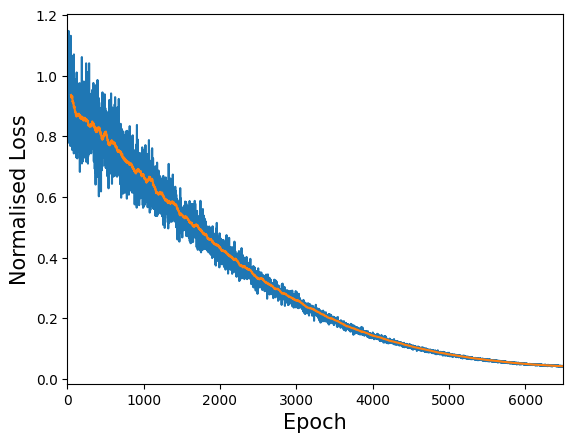

In [14]:
fig, ax = plt.subplots()

epochs_plot = torch.arange(len(loss_values))
epochs_avg = epochs_plot[window_size - 1:]
ax.plot(epochs_plot, loss_values.cpu().numpy(), label='Raw loss')

ax.plot(epochs_avg, mov_avg, label='Moving average')

ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Normalised Loss', fontsize=15)
ax.set_xlim(0, len(loss_values))

plt.show()

Estimate decay width and store parameters in CSV; plot event weights

In [17]:
def flow_decay_width_estimator(flow, B_total, chunk_size):

    flow = flow.to('cpu')
    flow.eval()

    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        events_all =[]
        weights_all = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)

            me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

            weights = prefactor * me2_vals * jac_dets * jac_map
            events = torch.stack((P, P1, P2, P3), dim=1)        #shape (b, 4, 4)

            events_all.append(events.detach().clone())
            weights_all.append(weights.detach().clone())

            sum_w += weights.sum()
            sum_w2 += (weights * weights).sum()
            n_total += b

            del Y, X, jac_dets, P, P1, P2, P3, jac_map, me2_vals, events, weights

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    events_all = torch.cat(events_all, dim=0)        #shape (N, 4, 4)
    weights_all = torch.cat(weights_all)             #shape (N,)

    return mean, stderr, events_all, weights_all

In [18]:
def uniform_decay_width_estimator(B_total, chunk_size):
    
    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    # optional one-off diagnostic check
    X_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
    (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
    element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
    del X_test, P1t, P2t, P3t

    events_all = []
    weights_all = []

    for i in range(0, B_total, chunk_size):
        b = min(chunk_size, B_total - i)

        X = torch.rand((b, 5), device='cpu', dtype=torch.float64)

        (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)

        me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

        events = torch.stack((P, P1, P2, P3), dim=1)

        weights = prefactor * me2_vals * jac_map
        events_all.append(events.detach().clone())
        weights_all.append(weights.detach().clone())

        sum_w += weights.sum()
        sum_w2 += (weights * weights).sum()
        n_total += b

        del X, P, P1, P2, P3, jac_map, me2_vals, events, weights

        if (i // chunk_size) % 10 == 0:
            gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    events_all = torch.cat(events_all, dim=0)
    weights_all = torch.cat(weights_all)

    return mean, stderr, events_all, weights_all

In [ ]:
def vegas_integrand(X):

    '''X is one point in [0,1]^5'''
    m_t=173
    (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
    p = [
        P,
        P1,
        P2,
        P3
    ]

    me2 = get_matrix_element(p)
    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)
    
    return prefactor * me2 * jac_map

integ = vegas.Integrator(5 * [[0.0, 1.0]])

result = integ(vegas_integrand, nitn=10, neval=1000)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [19]:
mean, stderr, events, weights = flow_decay_width_estimator(flow, B_total=1000000, chunk_size=100000)

print(f"Flow-derived decay width estimate = {mean} ± {stderr}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Flow-derived decay width estimate = 0.16376352106328654 ± 0.0001579699440716507


In [20]:
print(len(weights))

1000000


In [21]:
mean_u, stderr_u, events_u, weights_u = uniform_decay_width_estimator(B_total=1000000, chunk_size=100000)
print(f"Uniform-derived decay width estimate = {mean_u} ± {stderr_u}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Uniform-derived decay width estimate = 0.16376228474406568 ± 0.0007408483710838843


In [22]:
import pandas as pd
import os

def save_decay_result_pandas(filename, row_dict):
    df_row = pd.DataFrame([row_dict])

    if os.path.exists(filename):
        df_row.to_csv(filename, mode="a", header=False, index=False)
    else:
        df_row.to_csv(filename, index=False)

In [23]:
save_decay_result_pandas(
    "decay_width_results.csv",
    {
        "D": 5,
        "layer_type": "pwq_layer",
        "K": 64,
        "hidden_size": 16,
        "N": 8000,
        "epochs": 6500,
        "lr": 3e-5,
        "dtype": "float64",
        "B": 1000000,
        "final_loss": float(final_loss),
        "decay_width": float(mean),
        "decay_width_error": float(stderr),
    }
)

In [24]:
save_decay_result_pandas(
    "uniform_decay_width_results.csv",
    {
        "D": 5,
        "B": 1000000,
        "decay_width": float(mean_u),
        "decay_width_error": float(stderr_u),
    }
)

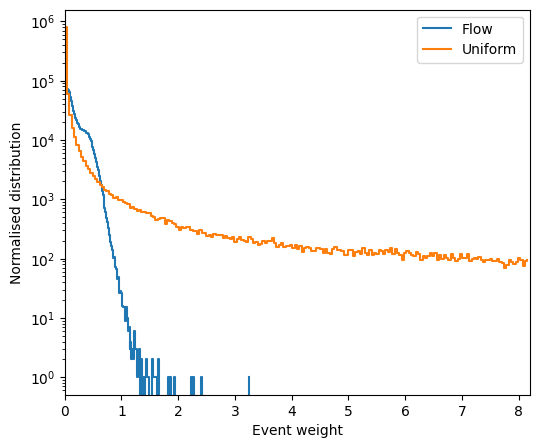

In [25]:
#histogram of weights
bins = 200

counts, bin_edges = np.histogram(weights, bins=bins, density=False)  #get histogram(s)
counts_u, bin_edges_u = np.histogram(weights_u, bins=bins, density=False)

plt.figure(figsize=(6,5))                                           #plot using step style bin edges

plt.step(bin_edges[:-1], counts, where='post', label='Flow')
plt.step(bin_edges_u[:-1], counts_u, where='post', label='Uniform')


plt.xlabel("Event weight")
plt.ylabel("Normalised distribution")
plt.yscale('log')

plt.xlim(0, bin_edges_u[-1])
#plt.xlim(0, 1)
plt.legend()

plt.show()



Unweighting

In [26]:
def unweight(events, weights):     

    print("Events:", events.shape)
    w_max = torch.max(weights)
    w_mean = torch.mean(weights)
    unweighted_events = []
    
    for event, weight in zip(events, weights):
        u = torch.rand(1)
        if u < (weight / w_max):
            unweighted_events.append(event)
    
    unweighted_events = torch.stack(unweighted_events, dim=0)
    print("Unweighted events:", unweighted_events.shape)
    efficiency = unweighted_events.size(0) / len(weights)

    return unweighted_events, efficiency
    

In [27]:
unweighted, efficiency = unweight(events, weights)

Events: torch.Size([1000000, 4, 4])
Unweighted events: torch.Size([50067, 4, 4])


In [28]:
print(efficiency)

0.050067


In [29]:
unweighted_u, efficiency_u = unweight(events_u, weights_u)

Events: torch.Size([1000000, 4, 4])
Unweighted events: torch.Size([19964, 4, 4])


In [30]:
print(efficiency_u)

0.019964


Plot histogram of (p_e+ + p_ve)^2; should see resonance around M_W^2

In [31]:
def W_products_momenta_hist(flow, B_total, chunk_size):

    '''Returns B_total values of (p_e+ + p_ve)^2'''

    flow = flow.to('cpu')
    flow.eval()
    
    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        P23square = []
        me2vals = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2 = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)
            minkowski_prod = (
                        (P2[:,0] + P3[:,0])**2
                        - (P2[:,1] + P3[:,1])**2
                        - (P2[:,2] + P3[:,2])**2
                        - (P2[:,3] + P3[:,3])**2
                    )

            P23square.append(minkowski_prod)
            me2vals.append(me2)

            del Y, X, jac_dets, P, P1, P2, P3, jac_map

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    P23square = torch.cat(P23square)
    me2vals = torch.cat(me2vals)
    #histogram of weights
    bins = 200

    counts, bin_edges = np.histogram(P23square, bins=bins, weights=me2vals, density=True)  #get histogram(s)

    plt.figure(figsize=(6,5))                                         

    plt.step(bin_edges[:-1], counts, where='post', label='Flow')            #plot using step style bin edges
    plt.vlines((6458), ymin=0, ymax=1e-3, colors='r', linestyles="dashed")


    plt.xlabel("$(P_{e+} + P_{ve})^2$")
    plt.ylabel("Normalised distribution")
    plt.yscale('log')
    plt.xlim(0)

    #plt.legend()

    plt.show()

In [32]:
def non_flow_W_products_momenta_hist(B_total, chunk_size):

    '''Returns B_total values of (p_e+ + p_ve)^2'''

    
    with torch.inference_mode():
        # optional one-off diagnostic check
        #Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        #X_test, _ = flow.inverse(Y_test)
        #(_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        #element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        #del Y_test, X_test, P1t, P2t, P3t

        P23square = []
        me2_vals = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            X = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2 = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)
            minkowski_prod = (
                        (P2[:,0] + P3[:,0])**2
                        - (P2[:,1] + P3[:,1])**2
                        - (P2[:,2] + P3[:,2])**2
                        - (P2[:,3] + P3[:,3])**2
                    )

            P23square.append(minkowski_prod)
            me2_vals.append(me2)

            del X, P, P1, P2, P3, jac_map

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    P23square = torch.cat(P23square)
    me2_vals = torch.cat(me2_vals)
    #histogram of weights
    bins = 200

    counts, bin_edges = np.histogram(P23square, bins=bins, weights=me2_vals, density=True)  #get histogram(s)

    plt.figure(figsize=(6,5))                                         

    plt.step(bin_edges[:-1], counts, where='post', label='Flow')            #plot using step style bin edges
    plt.vlines((6458), ymin=0, ymax=1e-3, colors='r', linestyles="dashed")


    plt.xlabel("$(P_{e+} + P_{ve})^2$")
    plt.ylabel("Normalised distribution")
    plt.yscale('log')
    plt.xlim(0)

    #plt.legend()

    plt.show()

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed


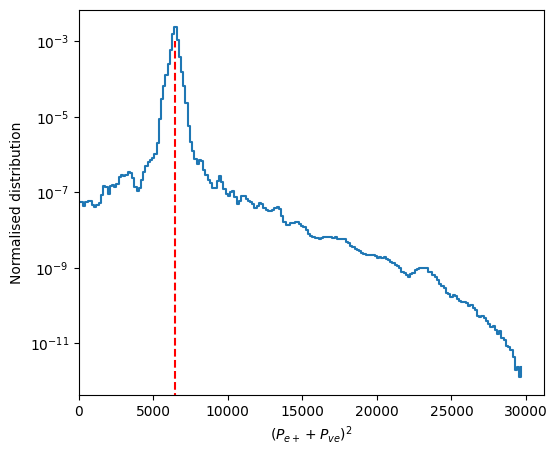

In [33]:
W_products_momenta_hist(flow, B_total=1_000_000, chunk_size=100_000)

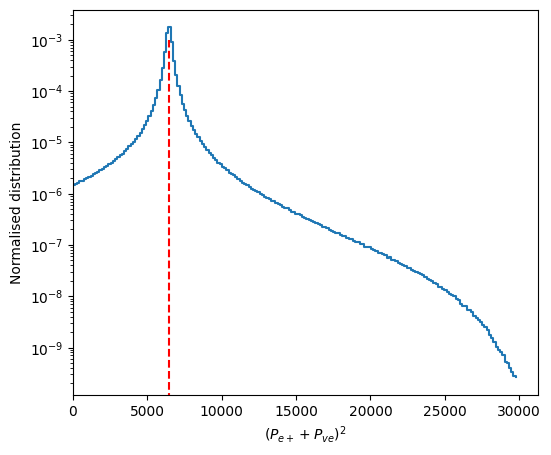

In [47]:
non_flow_W_products_momenta_hist(B_total=1_000_000, chunk_size=100_000)